# Стекинг ансамбль с использованием логистической регрессии с балансировкой весов

Используется устройство: cuda

=== Подготовка данных для Stacking ===


Предсказания ViTEmotion: 100%|██████████| 96/96 [00:16<00:00,  5.81it/s]


Размер признакового пространства: 21

Обучение мета-модели (Logistic Regression + balanced weights)

Сохранение мета-модели
Папка создана: D:\НИР\Final models\ensemble_results_
Мета-модель сохранена в D:\НИР\Final models\ensemble_results_/meta_model.pkl
РЕЗУЛЬТАТЫ STACKING (с balanced weights)
Val Accuracy:   0.9913
Test Accuracy:  0.8957
Test Macro F1:  0.8354

Per-class F1-score (Stacking + balanced):
              precision    recall  f1-score   support

    Surprise      0.902     0.894     0.898       329
        Fear      0.706     0.649     0.676        74
     Disgust      0.725     0.694     0.709       160
   Happiness      0.952     0.965     0.958      1185
     Sadness      0.887     0.854     0.870       478
       Anger      0.893     0.827     0.859       162
     Neutral      0.859     0.897     0.878       680

    accuracy                          0.896      3068
   macro avg      0.846     0.825     0.835      3068
weighted avg      0.895     0.896     0.895      30

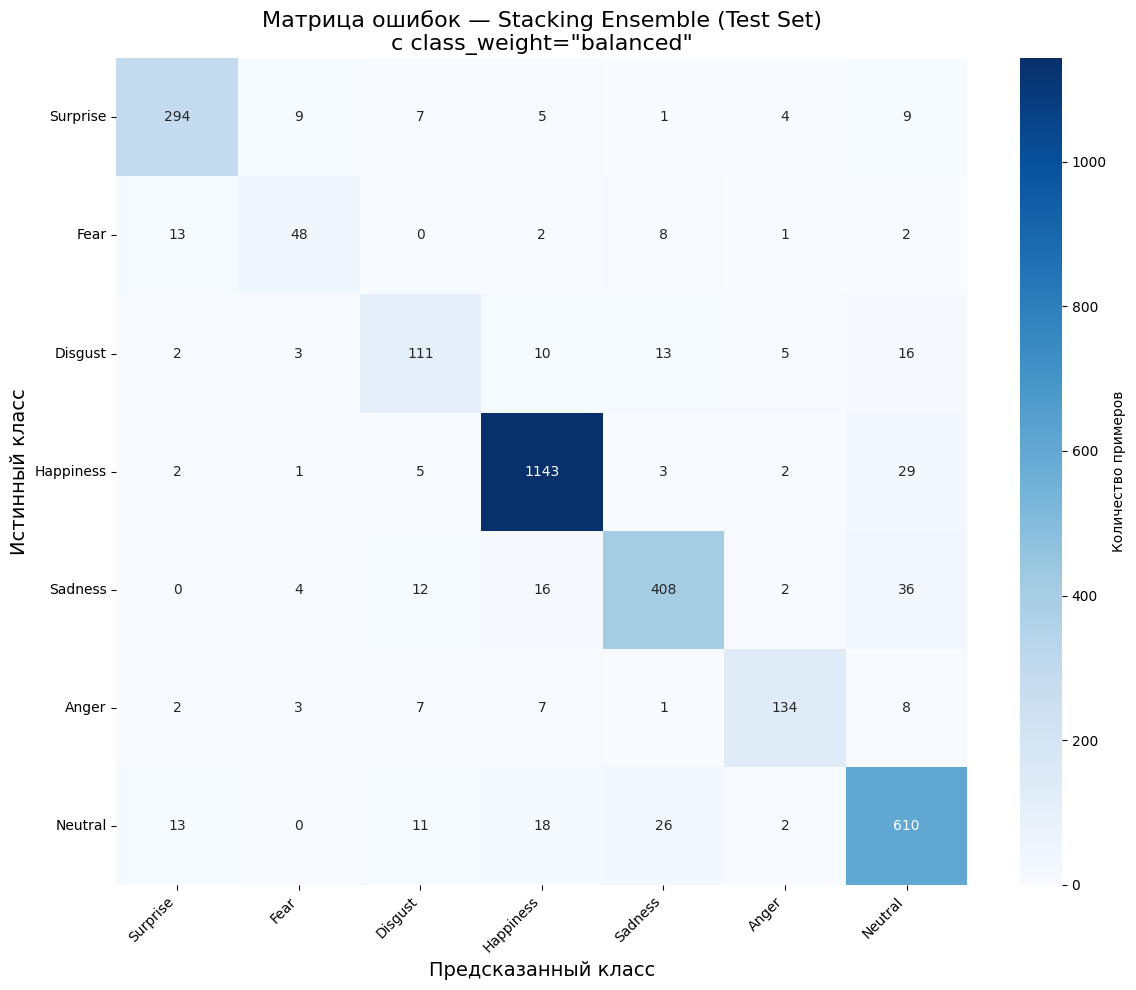

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import pickle
from pathlib import Path
from PIL import Image
import timm
import warnings
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import os

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

RAFDB_ROOT = r"D:\НИР\RAF-DB\DATASET"
SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"

PATH_EFF = r"D:\НИР\Final models\EfficientNet\best_model.pth"
PATH_CONV = r"D:\НИР\Final models\ConvNext\best_model.pth"
PATH_VIT = r"D:\НИР\Final models\ViT\best_model.pth"

RESULTS_DIR = r"D:\НИР\Final models\ensemble_results_"

BATCH_SIZE = 32

class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = tv_models.efficientnet_b2(
            weights=tv_models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
        )
        in_features = 1408
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        weights = tv_models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = tv_models.convnext_tiny(weights=weights)
        
        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(p=0.35),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class RAFDBDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir) / split
        self.is_train = 'train' in str(self.root_dir).lower()
        self.images = []
        self.labels = []
        self._load_data()

        self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)


class FixedSplitDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]


def create_dataloaders(batch_size=32):
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)

    full_train_base = RAFDBDataset(RAFDB_ROOT, 'train')
    test_ds = RAFDBDataset(RAFDB_ROOT, 'test')

    train_ds = FixedSplitDataset(full_train_base, splits['train_indices'])
    val_ds   = FixedSplitDataset(full_train_base, splits['val_indices'])

    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
        4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, pin_memory=True)

    return train_loader, val_loader, test_loader, emotion_labels


def load_model(model_class, path, num_classes=7):
    model = model_class(num_classes=num_classes).to(device)
    checkpoint = torch.load(path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model


model_eff = load_model(EfficientNetEmotion, PATH_EFF)
model_conv = load_model(ConvNeXtEmotion, PATH_CONV)
model_vit = load_model(ViTEmotion, PATH_VIT)

models = [model_eff, model_conv, model_vit]
model_names = ['EfficientNet-B2', 'ConvNeXt-Tiny', 'ViT-Small']


def get_model_probs(model, loader):
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Предсказания {model.__class__.__name__}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    
    return np.vstack(all_probs), np.concatenate(all_labels)


train_loader, val_loader, test_loader, emotion_labels = create_dataloaders(BATCH_SIZE)

print("\n=== Подготовка данных для Stacking ===")

val_probs_list = []
test_probs_list = []
val_labels = None
test_labels = None

for model in models:
    val_p, val_l = get_model_probs(model, val_loader)
    test_p, test_l = get_model_probs(model, test_loader)
    
    val_probs_list.append(val_p)
    test_probs_list.append(test_p)
    
    if val_labels is None:
        val_labels = val_l
        test_labels = test_l

X_val = np.hstack(val_probs_list)
X_test = np.hstack(test_probs_list)

print(f"Размер признакового пространства: {X_val.shape[1]}")

print("\nОбучение мета-модели (Logistic Regression + balanced weights)")

meta_model = LogisticRegression(
    max_iter=2000,
    C=0.8,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

meta_model.fit(X_val, val_labels)

print("\nСохранение мета-модели")

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Папка создана: {RESULTS_DIR}")

with open(f"{RESULTS_DIR}/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)
print(f"Мета-модель сохранена в {RESULTS_DIR}/meta_model.pkl")

val_pred = meta_model.predict(X_val)
test_pred = meta_model.predict(X_test)

print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))

print("\n")
print("МАТРИЦА ОШИБОК (Test Set)")


cm = confusion_matrix(test_labels, test_pred)

print("    " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()